In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
import pandas as pd
from IPython.display import HTML
import time

from numcosmo_py import Nc, Ncm
from numcosmo_py.sky_match import (
    BestCandidates,
    Coordinates,
    DistanceMethod,
    SelectionCriteria,
    SkyMatch,
    SkyMatchResult,
)
from astropy import units as u
from numcosmo_py.plotting.tools import set_rc_params_article, confidence_ellipse
from astropy.coordinates import SkyCoord, Angle
from scipy.special import erf
set_rc_params_article(ncol=1)
Ncm.cfg_init()

Omega_b = 0.0486
Omega_c = 0.2614
Omega_k = 0.0
H0 = 67.7

#Omega_b = 0.05
#Omega_c = 0.25
#Omega_k = 0.0
#H0 = 70.0

# Create a cosmology object
cosmo = Nc.HICosmoDEXcdm.new()
cosmo.omega_x2omega_k()
cosmo["Omegab"] = Omega_b
cosmo["Omegac"] = Omega_c
cosmo["Omegak"] = Omega_k
cosmo["H0"] = H0
cosmo["w"] = -1.0

dist = Nc.Distance.new(100.0)
dist.compute_inv_comoving(True)
dist.prepare(cosmo)

# Lets fix the numpy seed to get reproducible results
np.random.seed(74682)


In [2]:
# Constants
CLUSTER_LENGTH = 100
HALO_LENGTH = 200

RA_MIN, RA_MAX = -10.0, 10.0
DEC_MIN, DEC_MAX = -10.0, 10.0
Z_MIN, Z_MAX = 0.2, 0.5
LOGM_MIN, LOGM_MAX = 13.0, 15.0  # Mass in log10 solar masses
LOGM_ADD_HALO_MIN, LOGM_ADD_HALO_MAX = 10.0, 13.0

# Generate cluster positions, redshifts, and masses
cluster_ra = np.random.uniform(RA_MIN, RA_MAX, CLUSTER_LENGTH)
cluster_sin_dec = np.random.uniform(
    np.sin(np.radians(DEC_MIN)), np.sin(np.radians(DEC_MAX)), CLUSTER_LENGTH
)
cluster_dec = np.degrees(np.arcsin(cluster_sin_dec))
cluster_z = np.random.uniform(Z_MIN, Z_MAX, CLUSTER_LENGTH)
cluster_logm = np.random.uniform(LOGM_MIN, LOGM_MAX, CLUSTER_LENGTH)
# Let's compute the cluster radii, and the 3D positions
cluster_r = np.array(dist.comoving_array(cosmo, cluster_z)) * cosmo.RH_Mpc()
cluster_x1 = (
    cluster_r * np.cos(np.radians(cluster_dec)) * np.cos(np.radians(cluster_ra))
)
cluster_x2 = (
    cluster_r * np.cos(np.radians(cluster_dec)) * np.sin(np.radians(cluster_ra))
)
cluster_x3 = cluster_r * np.sin(np.radians(cluster_dec))

# Generate halo positions, redshifts, and masses
# Lets first sample a halo < 5.0 Mpc from the cluster in each dimension
D_DIM = 5.0

halo_x1 = cluster_x1 + np.random.uniform(-D_DIM, D_DIM, CLUSTER_LENGTH)
halo_x2 = cluster_x2 + np.random.uniform(-D_DIM, D_DIM, CLUSTER_LENGTH)
halo_x3 = cluster_x3 + np.random.uniform(-D_DIM, D_DIM, CLUSTER_LENGTH)
halo_ra = np.degrees(np.arctan2(halo_x2, halo_x1))
halo_dec = np.degrees(np.arcsin(halo_x3 / cluster_r))
halo_r = np.sqrt(halo_x1**2 + halo_x2**2 + halo_x3**2)
halo_z = [dist.inv_comoving(cosmo, r / cosmo.RH_Mpc()) for r in halo_r]

# Now for the halo masses we use the cluster's masses added a Gaussian noise
halo_logm = cluster_logm + np.random.normal(0, 1.0, CLUSTER_LENGTH)

# Finally we add 100 more halos randomly
DELTA_OBJECTS = HALO_LENGTH - CLUSTER_LENGTH
halo_ra = np.append(halo_ra, np.random.uniform(RA_MIN, RA_MAX, DELTA_OBJECTS))
halo_dec = np.append(halo_dec, np.random.uniform(DEC_MIN, DEC_MAX, DELTA_OBJECTS))
halo_z = np.append(halo_z, np.random.uniform(Z_MIN, Z_MAX, DELTA_OBJECTS))
halo_logm = np.append(
    halo_logm, np.random.uniform(LOGM_ADD_HALO_MIN, LOGM_ADD_HALO_MAX, DELTA_OBJECTS)
)

halos = Table([halo_ra, halo_dec, halo_z, halo_logm], 
              names=("RA", "DEC", "z", "Mass"), 
              dtype=(float, float, float, float))

clusters = Table([cluster_ra, cluster_dec, cluster_z, cluster_logm], 
              names=("RA", "DEC", "z", "Mass"), 
              dtype=(float, float, float, float))

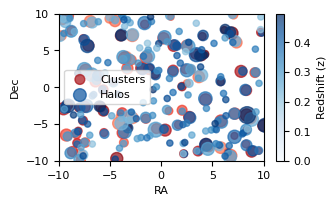

In [3]:
# Scale marker sizes with log mass
def scale_marker_size(log_mass, base_size=20, scale_factor=30):
    arr = scale_factor * (log_mass - LOGM_MIN)
    return base_size + np.where(arr < 0, 0, arr)


cluster_sizes = scale_marker_size(cluster_logm)
halo_sizes = scale_marker_size(halo_logm)

fig, ax = plt.subplots()

# Scatter plot for clusters (fixed red color)
ax.scatter(
    cluster_ra,
    cluster_dec,
    c=cluster_z,
    cmap="Reds",
    s=cluster_sizes,
    label="Clusters",
    alpha=0.7,
    vmin=0.0,
)

# Scatter plot for halos (color varies with z, from light to dark blue)
halo_scatter = ax.scatter(
    halo_ra,
    halo_dec,
    c=halo_z,
    cmap="Blues",
    s=halo_sizes,
    label="Halos",
    alpha=0.7,
    vmin=0.0,
)

# Colorbar to indicate redshift values
color_bar = plt.colorbar(halo_scatter, ax=ax, label="Redshift (z)")

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_xlim(RA_MIN, RA_MAX)
ax.set_ylim(DEC_MIN, DEC_MAX)
ax.legend()
plt.tight_layout()
plt.savefig("halos_clusters.pdf")
plt.show()

In [14]:
c_light = 299792.458 
def rho_crit(z):
   return  2.8*10**(11)*cosmo.h2() * ((cosmo["Omegac"]+cosmo["Omegab"])/(1+z)**3 + (1 - cosmo["Omegac"]-cosmo["Omegab"])) 

def get_galaxy_coords(ra_c, dec_c, sep_angular_rad, phi_rad):
    """
    Calcula RA e DEC de uma galáxia usando trigonometria esférica.
    
    Parâmetros:
    ra_c, dec_c: Coordenadas do centro (em graus)
    sep_angular_rad: galaxy_R / dA (em radianos)
    phi_rad: Ângulo de posição sorteado (em radianos)
    """
    
    # 1. Converter coordenadas do centro para radianos
    ra_c_rad = np.radians(ra_c)
    dec_c_rad = np.radians(dec_c)
    
    # 2. Calcular a Declinação (delta)
    # sin(delta) = sin(dec_c)cos(sep) + cos(dec_c)sin(sep)cos(phi)
    sin_dec = (np.sin(dec_c_rad) * np.cos(sep_angular_rad) + 
               np.cos(dec_c_rad) * np.sin(sep_angular_rad) * np.cos(phi_rad))
    
    dec_gal_rad = np.arcsin(sin_dec)
    
    # 3. Calcular a Ascensão Reta (alpha)
    # Usamos o termo y e x para o arctan2(y, x)
    y = np.sin(phi_rad) * np.sin(sep_angular_rad) * np.cos(dec_c_rad)
    x = np.cos(sep_angular_rad) - np.sin(dec_c_rad) * np.sin(dec_gal_rad)
    
    ra_gal_rad = ra_c_rad + np.arctan2(y, x)
    
    # 4. Converter de volta para graus e normalizar o RA para [0, 360]
    ra_gal = np.degrees(ra_gal_rad) % 360
    dec_gal = np.degrees(dec_gal_rad)
    
    return ra_gal, dec_gal

def HOD_model(m_halo, logMmin=12.72, sigma_logM=0.26, alpha=1.15, logM1=13.93, logM0=12.7):
    """
    Standard HOD model (Zheng et al. 2007)
    Returns number of centrals (0 or 1) and satellites (int)
    """
    # 1. Mean Central Occupancy (Error function)
    from scipy.special import erf
    mean_n_cen = 0.5 * (1 + erf((np.log10(m_halo) - logMmin) / sigma_logM))
    n_cen = 1 if np.random.random() < mean_n_cen else 0
    
    # 2. Mean Satellite Occupancy (Power Law)
    n_sat = 0
    if n_cen == 1:
        # Satellites only exist if a central exists
        mean_n_sat = ((m_halo - 10**logM0) / 10**logM1)**alpha
        if mean_n_sat > 0:
            n_sat = np.random.poisson(mean_n_sat)
            
    return n_cen, n_sat

In [15]:
halo_mass = 10**(halos['Mass'])
cluster_mass = 10**(clusters['Mass'])
halos['R200'] = ((3*(halo_mass))/(4*np.pi* 200*(rho_crit(halos['z']))))**(1/3)
clusters['R200'] = ((3*(cluster_mass))/(4*np.pi* 200*(rho_crit(clusters['z']))))**(1/3)

# Creating halo galaxy catalogs

In [22]:
np.random.seed(74682)
all_galaxies = []

for i in range(len(halos)):
    n_cen, n_sat = HOD_model(10**halos['Mass'][i])
    total_gals = n_cen + n_sat
    if total_gals == 0:
        continue
        
    # Generate local coordinates
    # Central is at (0,0,0), Satellites follow NFW/Uniform profile
    galaxy_R = np.zeros(total_gals)
    if n_sat > 0:
        # Satellites distributed within R200
        galaxy_R[n_cen:] = halos['R200'][i] * np.random.uniform(0, 1, n_sat)**(1/3)

    h_ra = halos['RA'][i]
    h_dec = halos['DEC'][i]
    h_z = halos['z'][i]
    h_r200 = halos['R200'][i]

    galaxy_R = h_r200 * np.random.uniform(0, 1, total_gals)**(1/3)
    costheta = np.random.uniform(-1, 1, total_gals)
    galaxy_theta = np.arccos(costheta)
    galaxy_phi = np.random.uniform(0, 2*np.pi, total_gals)

    Hz = cosmo.H(h_z)

    distancia_radial = galaxy_R * np.cos(galaxy_theta) 
    delta_z = (Hz / c_light) * distancia_radial
    z_galaxy = h_z + delta_z


    dA = dist.angular_diameter(cosmo, h_z) * cosmo.RH_Mpc()
    sep_angular = galaxy_R / dA 

    ra_g, dec_g = get_galaxy_coords(h_ra, h_dec, sep_angular, galaxy_phi)

    ra_corrected = ra_g % 360.0
    
    ra_corrected = np.where(ra_corrected > 180, ra_corrected - 360, ra_corrected)
    
    ra_corrected = np.clip(ra_corrected, RA_MIN, RA_MAX)
    
    
    temp_table = Table()

    temp_table['halo_id']  = np.full(total_gals, i)
    temp_table['RA'] = ra_corrected
    temp_table['DEC'] = dec_g
    temp_table['z'] = z_galaxy
    temp_table['is_central'] = [True if j < n_cen else False for j in range(total_gals)]
    temp_table['halo_RA']  = np.full(total_gals, h_ra)
    temp_table['halo_DEC'] = np.full(total_gals, h_dec)
    temp_table['halo_z']   = np.full(total_gals, h_z)
    
    all_galaxies.append(temp_table)

if all_galaxies:
    galaxy_halo_catalog = vstack(all_galaxies)
    galaxy_halo_catalog['galaxy_id'] = np.arange(len(galaxy_halo_catalog))
    
    # Reorder columns for readability
    ordered_cols = ['galaxy_id', 'halo_id', 'is_central', 'RA', 'DEC', 'z', 'halo_z']
    galaxy_halo_catalog = galaxy_halo_catalog[ordered_cols]
    
    print(f"Generated {len(galaxy_halo_catalog)} galaxies from {len(halos)} halos.")
    display(galaxy_halo_catalog[:10]) # Show first 10 rows
else:
    print("No galaxies were generated. Check your HOD mass thresholds.")

Generated 7074 galaxies from 200 halos.


/tmp/ipykernel_1228955/2772202554.py:53: RuntimeWarning: invalid value encountered in scalar power
  mean_n_sat = ((m_halo - 10**logM0) / 10**logM1)**alpha
/tmp/ipykernel_1228955/2772202554.py:53: RuntimeWarning: invalid value encountered in scalar power
  mean_n_sat = ((m_halo - 10**logM0) / 10**logM1)**alpha
/tmp/ipykernel_1228955/2772202554.py:53: RuntimeWarning: invalid value encountered in scalar power
  mean_n_sat = ((m_halo - 10**logM0) / 10**logM1)**alpha
/tmp/ipykernel_1228955/2772202554.py:53: RuntimeWarning: invalid value encountered in scalar power
  mean_n_sat = ((m_halo - 10**logM0) / 10**logM1)**alpha


galaxy_id,halo_id,is_central,RA,DEC,z,halo_z
int64,int64,bool,float64,float64,float64,float64
0,0,True,-5.75603704469421,-0.3167717479601696,0.429917256371976,0.42984934523315443
1,2,True,6.919921080659926,9.911025868721861,0.2492246606212074,0.2493043478530568
2,2,False,6.957413482708001,9.907684676774473,0.2492714035682601,0.2493043478530568
3,2,False,6.909757016562465,9.891826829645346,0.24924599169917805,0.2493043478530568
4,3,True,4.080715920848293,7.041786045903547,0.4528251335526976,0.4528776942921649
5,3,False,4.120353961975129,7.0646451745453085,0.4526226588298956,0.4528776942921649
6,3,False,4.0645061095718376,7.0061308171522345,0.45290669046519166,0.4528776942921649
7,3,False,4.126634813840513,7.02323023223861,0.45279497712638084,0.4528776942921649
8,3,False,4.131770392319192,7.007229836118845,0.45264361773630646,0.4528776942921649


# Creating cluster galaxy catalog

In [28]:
np.random.seed(74682)
all_galaxies = []

for i in range(len(clusters)):
    n_cen, n_sat = HOD_model(10**clusters['Mass'][i])
    
    total_gals = n_cen + n_sat
    if total_gals == 0:
        continue
        
    # Generate local coordinates
    # Central is at (0,0,0), Satellites follow NFW/Uniform profile
    galaxy_R = np.zeros(total_gals)
    if n_sat > 0:
        # Satellites distributed within R200
        galaxy_R[n_cen:] = clusters['R200'][i] * np.random.uniform(0, 1, n_sat)**(1/3)

    c_ra = clusters['RA'][i]
    c_dec = clusters['DEC'][i]
    c_z = clusters['z'][i]
    c_r200 = clusters['R200'][i]

    galaxy_R = c_r200 * np.random.uniform(0, 1, total_gals)**(1/3)
    costheta = np.random.uniform(-1, 1, total_gals)
    galaxy_theta = np.arccos(costheta)
    galaxy_phi = np.random.uniform(0, 2*np.pi, total_gals)

    Hz = cosmo.H(c_z)

    distancia_radial = galaxy_R * np.cos(galaxy_theta) 
    delta_z = (Hz / c_light) * distancia_radial
    z_galaxy = c_z + delta_z


    dA = dist.angular_diameter(cosmo, c_z) * cosmo.RH_Mpc()
    sep_angular = galaxy_R / dA 

    ra_g, dec_g = get_galaxy_coords(c_ra, c_dec, sep_angular, galaxy_phi)

    ra_corrected = ra_g % 360.0
    
    ra_corrected = np.where(ra_corrected > 180, ra_corrected - 360, ra_corrected)
    
    ra_corrected = np.clip(ra_corrected, RA_MIN, RA_MAX)
    
    
    temp_table = Table()

    temp_table['cluster_id']  = np.full(total_gals, i)
    temp_table['RA'] = ra_corrected
    temp_table['DEC'] = dec_g
    temp_table['z'] = z_galaxy
    temp_table['is_central'] = [True if j < n_cen else False for j in range(total_gals)]
    temp_table['cluster_RA']  = np.full(total_gals, h_ra)
    temp_table['cluster_DEC'] = np.full(total_gals, h_dec)
    temp_table['cluster_z']   = np.full(total_gals, h_z)
    
    all_galaxies.append(temp_table)

if all_galaxies:
    galaxy_cluster_catalog = vstack(all_galaxies)
    galaxy_cluster_catalog['galaxy_id'] = np.arange(len(galaxy_cluster_catalog))
    
    # Reorder columns for readability
    ordered_cols = ['galaxy_id', 'cluster_id', 'is_central', 'RA', 'DEC', 'z', 'cluster_z']
    galaxy_cluster_catalog = galaxy_cluster_catalog[ordered_cols]
    
    print(f"Generated {len(galaxy_cluster_catalog)} galaxies from {len(clusters)} clusters.")
    display(galaxy_cluster_catalog[:10]) # Show first 10 rows
else:
    print("No galaxies were generated. Check your HOD mass thresholds.")

Generated 447 galaxies from 100 clusters.
galaxy_id cluster_id is_central ...          z              cluster_z     
--------- ---------- ---------- ... ------------------- ------------------
        0          0       True ...  0.4302232300952835 0.4303325331850548
        1          0      False ... 0.43009476144508607 0.4303325331850548
        2          0      False ... 0.43038338535403003 0.4303325331850548
        3          0      False ... 0.43019342895418117 0.4303325331850548
        4          1       True ...  0.4400864989951944 0.4303325331850548
        5          2       True ... 0.24816360693121736 0.4303325331850548
        6          3       True ... 0.45294040818526965 0.4303325331850548
        7          4       True ...  0.3644801532716659 0.4303325331850548
        8          5       True ... 0.48440981337217076 0.4303325331850548
        9          5      False ... 0.48424271929796536 0.4303325331850548
